In [1]:
print("Test")

Test


Pour avoir une idée sur l'environnement on importe la librairie platform

In [2]:
import platform

In [3]:
# Get the Python version
platform.python_version()

'3.13.6'

Installation de pandas qui est une bibliothèque open source très utilisée pour la manipulation et l'analyse de données en Python. on utilise la commande pip install pandas dans le terminal

In [4]:
import pandas as pd 

In [5]:
df = pd.read_csv("dataset/prix_maisons.csv")

In [6]:
df.head()

,area,price
0,100,1218000
1,120,1440000
2,150,1800000
3,260,2860000
4,320,2880000


In [7]:
# Display information about the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   area    5 non-null      int64
 1   price   5 non-null      int64
dtypes: int64(2)
memory usage: 212.0 bytes


In [8]:
#print the number of null values in each column(feature)
df.isna().sum()

area     0
price    0
dtype: int64

In [9]:
# Statistical summary of the DataFrame
df.describe()
#To see  clearly we can transpose the result
df.describe().T

,count,mean,std,min,25%,50%,75%,max
area,5.0,190.0,95.393920,100.0,120.0,150.0,260.0,320.0
price,5.0,2039600.0,786015.775923,1218000.0,1440000.0,1800000.0,2860000.0,2880000.0


matplotlib: pour la visualisation des données sous forme de graphiques

In [10]:
import matplotlib.pyplot as plt

Text(0, 0.5, 'Prix en DH (en milliers)')

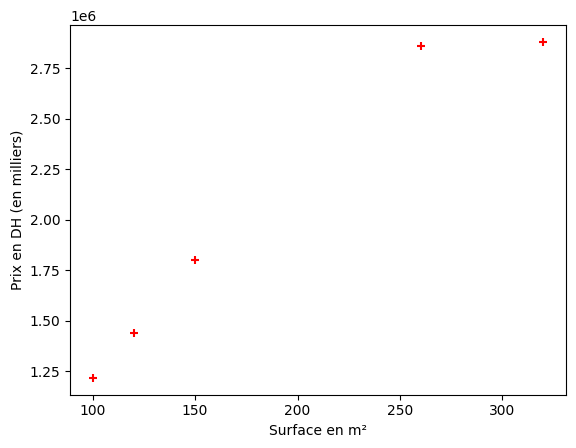

In [11]:
# dessin de nuage de points
plt.scatter(df['area'], df['price'],color= 'red',marker= '+')
plt.xlabel('Surface en m²')
plt.ylabel('Prix en DH (en milliers)')



In [12]:
#import de linear_model de la bibliothèque sklearn: pour la régression linéaire
from sklearn import linear_model

In [13]:
#creation de notre modèle de régression linéaire
model = linear_model.LinearRegression() # algorithme de régression linéaire

Entraînement du modèle

In [14]:
# séparation des variables features et target
y = df['price'] # variable cible
X = df.drop(columns=['price']) # variable feature

print(X.head())
print(y.head())

   area
0   100
1   120
2   150
3   260
4   320
0    1218000
1    1440000
2    1800000
3    2860000
4    2880000
Name: price, dtype: int64


In [15]:
model.fit(X, y)  # entrainement du modèle

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [16]:
#Prediction du prix d'une maison de 250 m²
predicted_price = model.predict([[250]])
print(f"Le prix prédit pour une maison de 250 m² est de {predicted_price[0]:.2f} DH")



Le prix prédit pour une maison de 250 m² est de 2521215.38 DH


C:\Users\Binta\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Affichage de la fonction lineare sur la figure

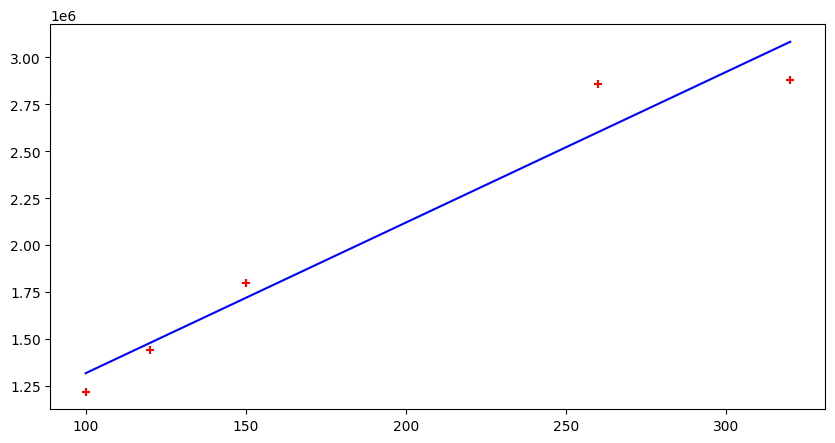

In [17]:
plt.figure(figsize = (10,5)) #taille de la figure largeur, hauteur
plt.scatter(df['area'], df['price'], color='red', marker='+')
# tracer la ligne de régression
plt.plot(
      X, # valeurs de x
      model.predict(X), # valeurs prédites par le modèle
      color='blue'# couleur de la ligne de régression
      ) 

Evaluation du model par des metrics

In [18]:
from sklearn import metrics

In [19]:
metrics.r2_score(y, model.predict(X))
#This is not a good practice to evaluate the model on the same data used for training
# We should split the data into training and testing sets

0.9490237236328821

2ème dataset

In [20]:
df2 = pd.read_csv('dataset/prix_maisons2.csv')

In [21]:
df2.head()

,area,rooms,age,city,price
0,100,3.0,4,Casablanca,1500000
1,120,4.0,10,Casablanca,1680000
2,260,NaN,20,Casablanca,3380000
3,190,5.0,1,Casablanca,3040000
4,260,5.0,4,Casablanca,3900000


In [22]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   area    18 non-null     int64  
 1   rooms   15 non-null     float64
 2   age     18 non-null     int64  
 3   city    18 non-null     object 
 4   price   18 non-null     int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 852.0+ bytes


In [23]:
df2.isna().sum()

area     0
rooms    3
age      0
city     0
price    0
dtype: int64

In [24]:
median = df2['rooms'].median()
median

np.float64(4.0)

In [25]:
# On remplace les valeurs manquantes de la colonne rooms par la medanne 
df2.fillna({'rooms': median}, inplace=True)

In [26]:
from sklearn import preprocessing # pour le prétraitement des données

In [27]:
encoder = preprocessing.LabelEncoder()

In [28]:
df2['city_label'] = encoder.fit_transform(df2['city']) # encodage des villes en valeurs numériques

import de la bibliothèque seaborn pour l'utilisation des histogramme afin de visualiser la distribution des données

In [29]:
import seaborn as sns

<Axes: xlabel='area', ylabel='Count'>

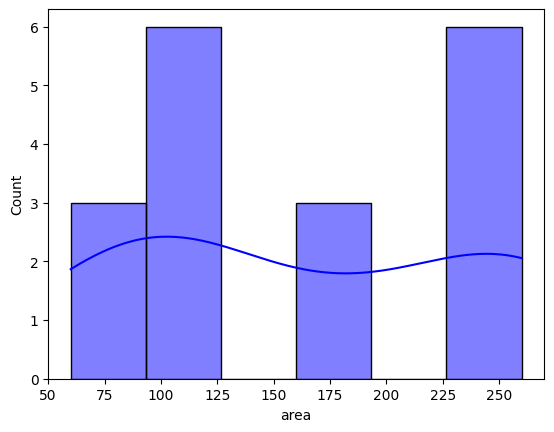

In [30]:
# Visualisation de la distribution de la surface des maisons
sns.histplot(
        df2['area'], # la variable à visualiser
        kde=True, # pour ajouter une courbe de densité
        color='blue', # couleur de la distribution
        #bins=5 # nombre de barres dans l'histogramme
        )

In [31]:
y2 = df2['price']
X2 = df2.drop(columns= ['price', 'city'])

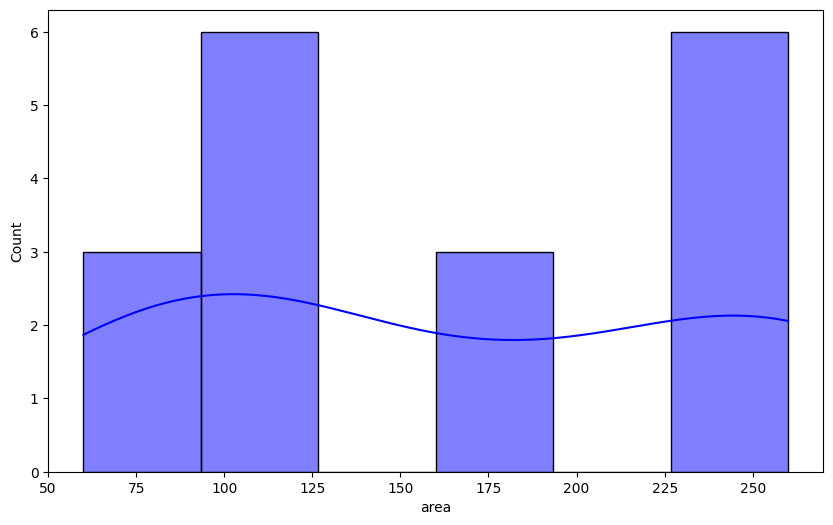

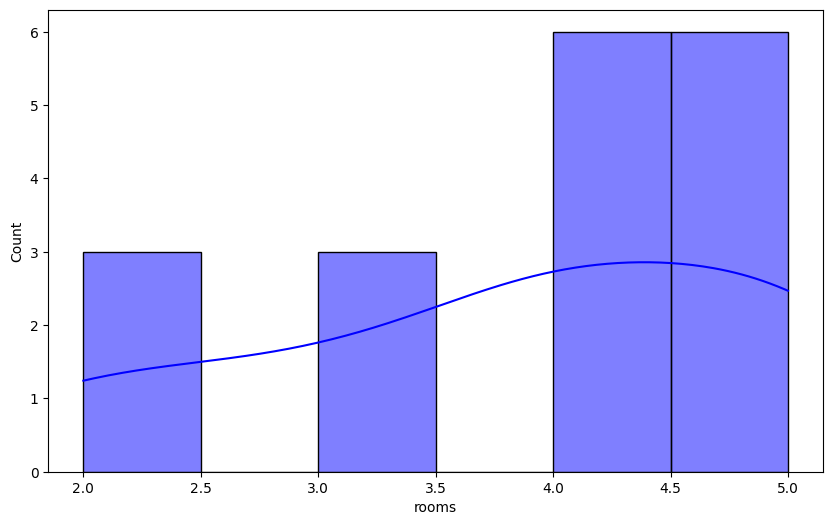

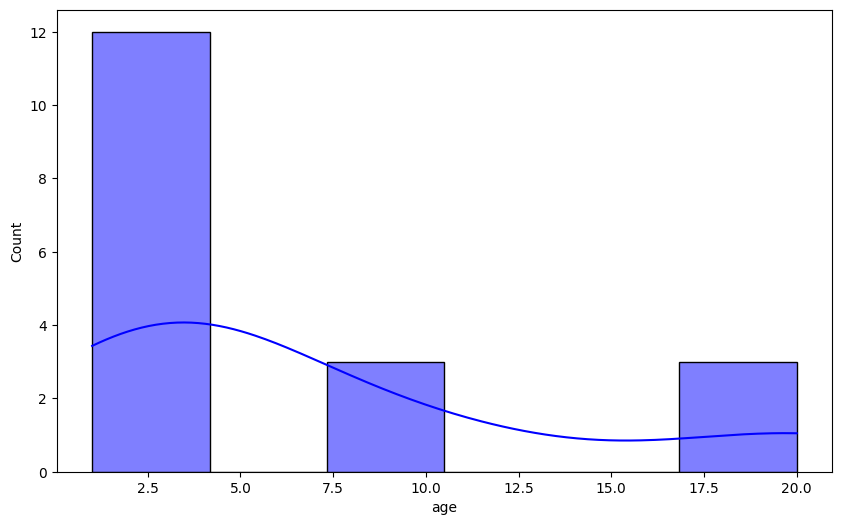

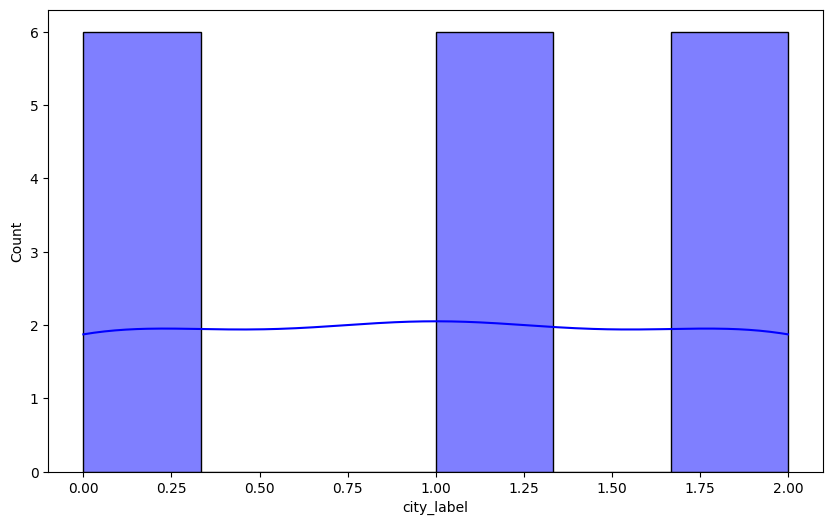

In [32]:
# Histogramme pour chaque feature
for col in X2.columns:
    plt.figure(figsize = (10,6))
    sns.histplot(X2[col], kde=True,color='blue')
plt.show()

Calcul des correlation

In [33]:
X2.corr()

,area,rooms,age,city_label
area,1.000000,7.969505e-01,4.286814e-01,0.000000e+00
rooms,0.796950,1.000000e+00,3.076948e-01,-2.831409e-17
age,0.428681,3.076948e-01,1.000000e+00,-2.819969e-17
city_label,0.000000,-2.831409e-17,-2.819969e-17,1.000000e+00


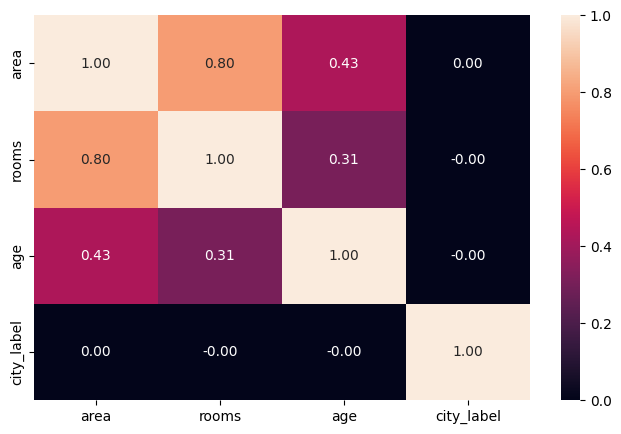

In [34]:
plt.figure(figsize=(8,5))
cmap = sns.diverging_palette(230,20,as_cmap=True) # return un map de couleur
sns.heatmap(
    X2.corr(),   # 👉 La matrice de corrélation calculée à partir du DataFrame X2.
                 #    Chaque case montre la force du lien entre deux variables.

    annot=True,  # 👉 Affiche les valeurs numériques directement dans les cases du heatmap.
                 #   

    fmt='.2f'    # 👉 Formate les nombres affichés avec 2 chiffres après la virgule.
                 #    Exemple : 0.756 devient 0.76
)

plt.show()

## **Model Building - Approach**

1. Data preparation
2. Partition the data into train and test set
3. Build model on the train data
4. Test the data on test set

### **Split the dataset**
Let's split the data into the dependent and independent variables and further split it into train and test set in a ratio of 70:30 for train and test set.

In [ ]:
from sklearn.model_selection import train_test_split
X2_train,X2_test,y2_train,y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)


In [37]:
X2_train.shape

(12, 4)

In [38]:
model2 = linear_model.LinearRegression()

In [39]:
model2.fit(X2_train,y2_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [40]:
predicted_train = model2.predict(X2_train)
predicted_test= model2.predict(X2_test)

In [41]:
metrics.r2_score(y2_train,predicted_train)

0.9670552480169055